In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/telco_churn.csv")

print("========================================")
print("DATASET CARGADO CORRECTAMENTE")
print("========================================")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

DATASET CARGADO CORRECTAMENTE
Filas: 7043
Columnas: 21


In [2]:
# ==========================================
# PASO 2 - LIMPIEZA DE TOTALCHARGES
# ==========================================

# Eliminar espacios en blanco
df["TotalCharges"] = df["TotalCharges"].str.strip()

# Convertir a número
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Tipo de TotalCharges:")
print(df["TotalCharges"].dtype)

print("\nValores nulos después de la conversión:")
print(df["TotalCharges"].isnull().sum())

Tipo de TotalCharges:
float64

Valores nulos después de la conversión:
11


In [3]:
# ==========================================
# PASO 3 - ANALIZAR LOS VALORES NULOS
# ==========================================

print("Registros con TotalCharges nulo:")
print(
    df[df["TotalCharges"].isnull()]
    [["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]
)

Registros con TotalCharges nulo:
      customerID  tenure  MonthlyCharges  TotalCharges Churn
488   4472-LVYGI       0           52.55           NaN    No
753   3115-CZMZD       0           20.25           NaN    No
936   5709-LVOEQ       0           80.85           NaN    No
1082  4367-NUYAO       0           25.75           NaN    No
1340  1371-DWPAZ       0           56.05           NaN    No
3331  7644-OMVMY       0           19.85           NaN    No
3826  3213-VVOLG       0           25.35           NaN    No
4380  2520-SGTTA       0           20.00           NaN    No
5218  2923-ARZLG       0           19.70           NaN    No
6670  4075-WKNIU       0           73.35           NaN    No
6754  2775-SEFEE       0           61.90           NaN    No


In [4]:
# ==========================================
# PASO 4 - COMPLETAR TOTALCHARGES
# ==========================================

# Los clientes con tenure = 0 no tienen cargos acumulados.
# Por eso, los valores nulos de TotalCharges se reemplazan por 0.

df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Valores nulos después de la limpieza:")
print(df["TotalCharges"].isnull().sum())

print("\nTipo de TotalCharges:")
print(df["TotalCharges"].dtype)

Valores nulos después de la limpieza:
0

Tipo de TotalCharges:
float64


In [5]:
# ==========================================
# PASO 5 - COMPROBAR DUPLICADOS
# ==========================================

duplicados = df.duplicated().sum()

print("Cantidad de filas duplicadas:", duplicados)

if duplicados == 0:
    print("No se encontraron duplicados. No es necesario eliminar registros.")
else:
    df = df.drop_duplicates()
    print("Duplicados eliminados.")

Cantidad de filas duplicadas: 0
No se encontraron duplicados. No es necesario eliminar registros.


In [6]:
# ==========================================
# PASO 6 - CREACIÓN DE NUEVOS FEATURES
# ==========================================

# FEATURE 1: ClienteAntiguo
# 1 = cliente con más de 24 meses
# 0 = cliente con 24 meses o menos

df["ClienteAntiguo"] = (df["tenure"] > 24).astype(int)


# FEATURE 2: GastoPromedioMensual
# Calculamos el gasto promedio mensual del cliente

df["GastoPromedioMensual"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)


# Mostrar los nuevos features
print("Nuevos features creados:")
print(df[[
    "customerID",
    "tenure",
    "TotalCharges",
    "MonthlyCharges",
    "ClienteAntiguo",
    "GastoPromedioMensual"
]].head(10))

Nuevos features creados:
   customerID  tenure  TotalCharges  MonthlyCharges  ClienteAntiguo  \
0  7590-VHVEG       1         29.85           29.85               0   
1  5575-GNVDE      34       1889.50           56.95               1   
2  3668-QPYBK       2        108.15           53.85               0   
3  7795-CFOCW      45       1840.75           42.30               1   
4  9237-HQITU       2        151.65           70.70               0   
5  9305-CDSKC       8        820.50           99.65               0   
6  1452-KIOVK      22       1949.40           89.10               0   
7  6713-OKOMC      10        301.90           29.75               0   
8  7892-POOKP      28       3046.05          104.80               1   
9  6388-TABGU      62       3487.95           56.15               1   

   GastoPromedioMensual  
0             29.850000  
1             55.573529  
2             54.075000  
3             40.905556  
4             75.825000  
5            102.562500  
6          

In [7]:
# ==========================================
# PASO 7 - VALIDAR LOS NUEVOS FEATURES
# ==========================================

print("Valores nulos en ClienteAntiguo:")
print(df["ClienteAntiguo"].isnull().sum())

print("\nValores nulos en GastoPromedioMensual:")
print(df["GastoPromedioMensual"].isnull().sum())

print("\nCantidad total de columnas:")
print(df.shape[1])

print("\nCantidad total de filas:")
print(df.shape[0])

Valores nulos en ClienteAntiguo:
0

Valores nulos en GastoPromedioMensual:
0

Cantidad total de columnas:
23

Cantidad total de filas:
7043


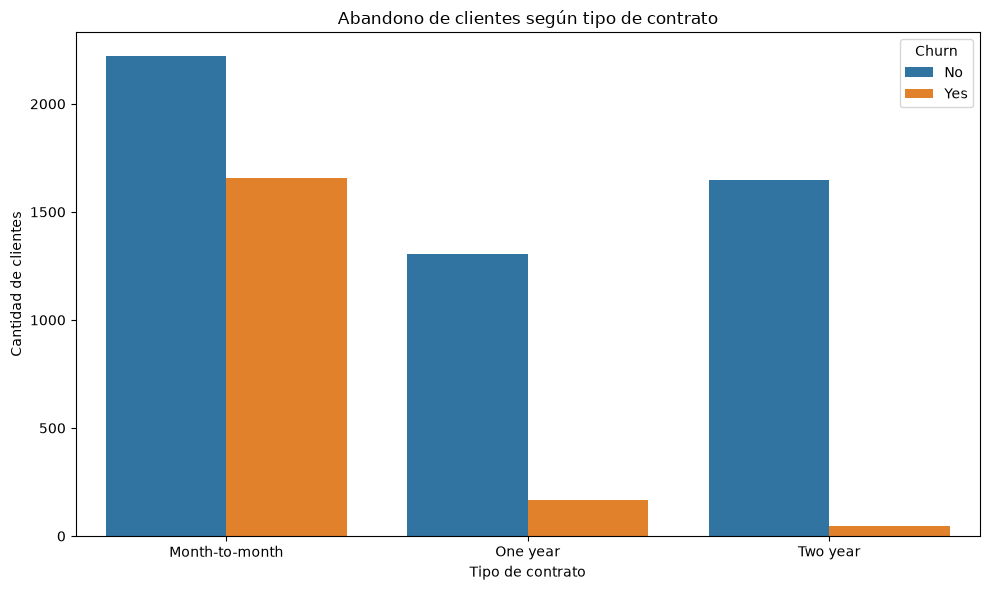

In [10]:
# ==========================================
# PASO 4 - VISUALIZACIÓN 1
# CHURN SEGÚN TIPO DE CONTRATO
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Abandono de clientes según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")

plt.tight_layout()

# Guardar gráfica
plt.savefig("../graficas/churn_por_contrato.png")

plt.show()

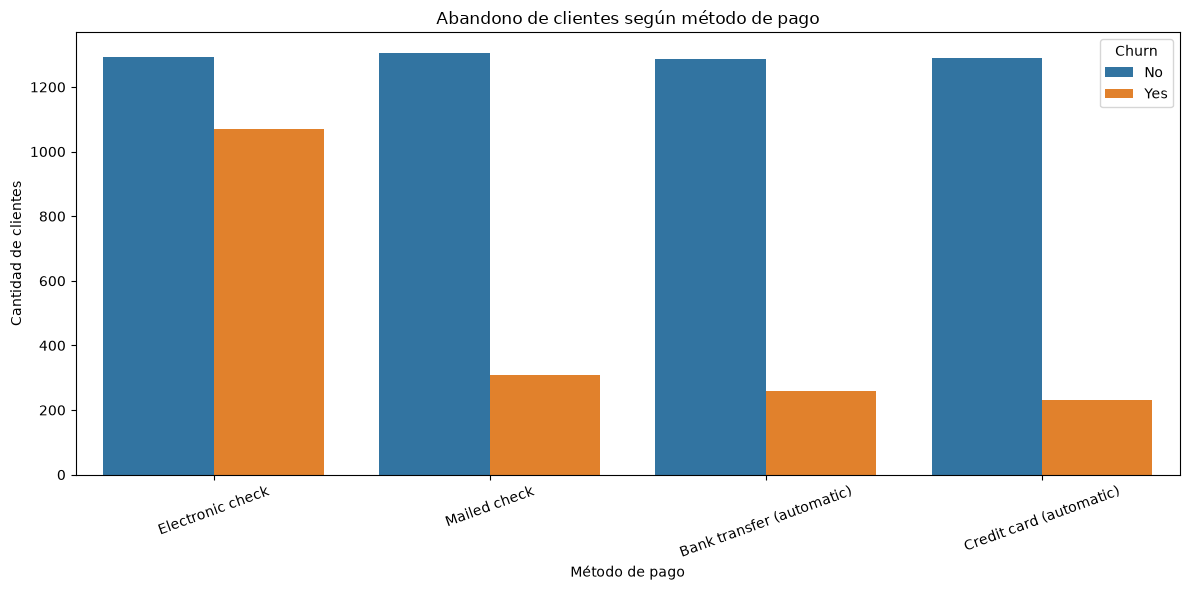

In [11]:
# ==========================================
# PASO 5 - VISUALIZACIÓN 2
# CHURN SEGÚN MÉTODO DE PAGO
# ==========================================

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Abandono de clientes según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad de clientes")

plt.xticks(rotation=20)

plt.tight_layout()

# Guardar gráfica
plt.savefig("../graficas/churn_por_metodo_pago.png")

plt.show()

In [12]:
# Variable objetivo
y = df["Churn"]

# Variables predictoras
X = df.drop("Churn", axis=1)

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (7043, 20)
Dimensiones de y: (7043,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 20)
X_test: (1409, 20)
y_train: (5634,)
y_test: (1409,)


In [14]:
# Verificar valores nulos
print("Valores nulos:")
print(df.isnull().sum())

Valores nulos:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [15]:
# Identificar columnas categóricas y numéricas

columnas_categoricas = X_train.select_dtypes(include=["object"]).columns.tolist()
columnas_numericas = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Columnas categóricas:")
print(columnas_categoricas)

print("\nColumnas numéricas:")
print(columnas_numericas)

Columnas categóricas:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

Columnas numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges']


/var/folders/z_/87rz1yy54ps1ms2ll1yjvkcw0000gn/T/ipykernel_43123/1309976857.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = X_train.select_dtypes(include=["object"]).columns.tolist()


In [17]:
# Eliminar customerID porque es solamente un identificador
X = df.drop(["Churn", "customerID"], axis=1)

# Asegurar que TotalCharges sea numérica
X["TotalCharges"] = pd.to_numeric(X["TotalCharges"], errors="coerce")

# Verificar el tipo de datos
print(X.dtypes)

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object


In [18]:
# Dividir nuevamente los datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [19]:
# Identificar columnas categóricas y numéricas

columnas_categoricas = X_train.select_dtypes(include="str").columns.tolist()
columnas_numericas = X_train.select_dtypes(exclude="str").columns.tolist()

print("Columnas categóricas:")
print(columnas_categoricas)

print("\nColumnas numéricas:")
print(columnas_numericas)

Columnas categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Columnas numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [20]:
from sklearn.preprocessing import OneHotEncoder

# Crear el encoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Aprender las categorías SOLO con X_train
X_train_encoded = encoder.fit_transform(X_train[columnas_categoricas])

# Aplicar el mismo encoder a X_test
X_test_encoded = encoder.transform(X_test[columnas_categoricas])

print("X_train_encoded:", X_train_encoded.shape)
print("X_test_encoded:", X_test_encoded.shape)

X_train_encoded: (5634, 41)
X_test_encoded: (1409, 41)


In [21]:
import numpy as np

# Obtener las variables numéricas
X_train_numericas = X_train[columnas_numericas].values
X_test_numericas = X_test[columnas_numericas].values

# Combinar variables numéricas + variables categóricas codificadas
X_train_procesado = np.hstack([
    X_train_numericas,
    X_train_encoded
])

X_test_procesado = np.hstack([
    X_test_numericas,
    X_test_encoded
])

print("X_train_procesado:", X_train_procesado.shape)
print("X_test_procesado:", X_test_procesado.shape)

X_train_procesado: (5634, 45)
X_test_procesado: (1409, 45)


In [22]:
from sklearn.preprocessing import StandardScaler

# Crear el scaler
scaler = StandardScaler()

# Escalar SOLO las variables numéricas
X_train_numericas_escaladas = scaler.fit_transform(
    X_train[columnas_numericas]
)

# Aplicar el mismo scaler a X_test
X_test_numericas_escaladas = scaler.transform(
    X_test[columnas_numericas]
)

print("X_train_numericas_escaladas:", X_train_numericas_escaladas.shape)
print("X_test_numericas_escaladas:", X_test_numericas_escaladas.shape)

X_train_numericas_escaladas: (5634, 4)
X_test_numericas_escaladas: (1409, 4)


In [23]:
# Combinar variables numéricas escaladas + variables categóricas codificadas

X_train_final = np.hstack([
    X_train_numericas_escaladas,
    X_train_encoded
])

X_test_final = np.hstack([
    X_test_numericas_escaladas,
    X_test_encoded
])

print("X_train_final:", X_train_final.shape)
print("X_test_final:", X_test_final.shape)

X_train_final: (5634, 45)
X_test_final: (1409, 45)


In [24]:
# Obtener nombres de las columnas generadas por One-Hot Encoding
columnas_encoded = encoder.get_feature_names_out(columnas_categoricas)

# Combinar nombres numéricos + nombres del encoding
columnas_finales = columnas_numericas + list(columnas_encoded)

print("Cantidad de columnas finales:", len(columnas_finales))
print("\nPrimeras columnas:")
print(columnas_finales[:10])

Cantidad de columnas finales: 45

Primeras columnas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes']


In [ ]:
# Crear DataFrames finales

X_train_df = pd.DataFrame(
    X_train_final,
    columns=columnas_finales,
    index=X_train.index
)

X_test_df = pd.DataFrame(
    X_test_final,
    columns=columnas_finales,
    index=X_test.index
)

y_train_df = pd.DataFrame(
    y_train,
    index=y_train.index
)

y_test_df = pd.DataFrame(
    y_test,
    index=y_test.index
)

# Guardar los 4 archivos CSV

X_train_df.to_csv("X_train.csv", index=False)
X_test_df.to_csv("X_test.csv", index=False)
y_train_df.to_csv("y_train.csv", index=False)
y_test_df.to_csv("y_test.csv", index=False)

print("Archivos CSV creados correctamente:")
print("X_train.csv")
print("X_test.csv")
print("y_train.csv")
print("y_test.csv")

✅ Archivos CSV creados correctamente:
X_train.csv
X_test.csv
y_train.csv
y_test.csv


In [26]:
# Verificar los archivos CSV

X_train_check = pd.read_csv("X_train.csv")
X_test_check = pd.read_csv("X_test.csv")
y_train_check = pd.read_csv("y_train.csv")
y_test_check = pd.read_csv("y_test.csv")

print("X_train.csv:", X_train_check.shape)
print("X_test.csv:", X_test_check.shape)
print("y_train.csv:", y_train_check.shape)
print("y_test.csv:", y_test_check.shape)

print("\nPrimeras 5 columnas de X_train:")
print(X_train_check.columns[:5].tolist())

print("\nPrimeras filas de X_train:")
display(X_train_check.head())

X_train.csv: (5634, 45)
X_test.csv: (1409, 45)
y_train.csv: (5634, 1)
y_test.csv: (1409, 1)

Primeras 5 columnas de X_train:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Female']

Primeras filas de X_train:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.441773,0.102371,-0.521976,-0.263695,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-0.441773,-0.711743,0.337478,-0.505076,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.441773,-0.793155,-0.809013,-0.751328,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.441773,-0.263980,0.284384,-0.174159,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,-0.441773,-1.281624,-0.676279,-0.990822,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [27]:
X_train_df.to_csv("X_train.csv", index=False)